Original Time Series Head:
2020-01-01    0.248357
2020-01-02    0.131517
2020-01-03    0.716981
2020-01-04    1.331149
2020-01-05    0.605886
2020-01-06    0.729817
2020-01-07    1.725969
2020-01-08    1.371472
2020-01-09    0.764234
2020-01-10    1.240836
Freq: D, dtype: float64


Simple Average Smoothed Series (Window 5) Head:
2020-01-01         NaN
2020-01-02         NaN
2020-01-03         NaN
2020-01-04         NaN
2020-01-05    0.606778
2020-01-06    0.703070
2020-01-07    1.021960
2020-01-08    1.152859
2020-01-09    1.039476
2020-01-10    1.166466
Freq: D, dtype: float64


Exponentially Smoothed Series (Span 5) Head:
2020-01-01    0.248357
2020-01-02    0.209410
2020-01-03    0.378600
2020-01-04    0.696117
2020-01-05    0.666040
2020-01-06    0.687299
2020-01-07    1.033522
2020-01-08    1.146172
2020-01-09    1.018859
2020-01-10    1.092852
Freq: D, dtype: float64




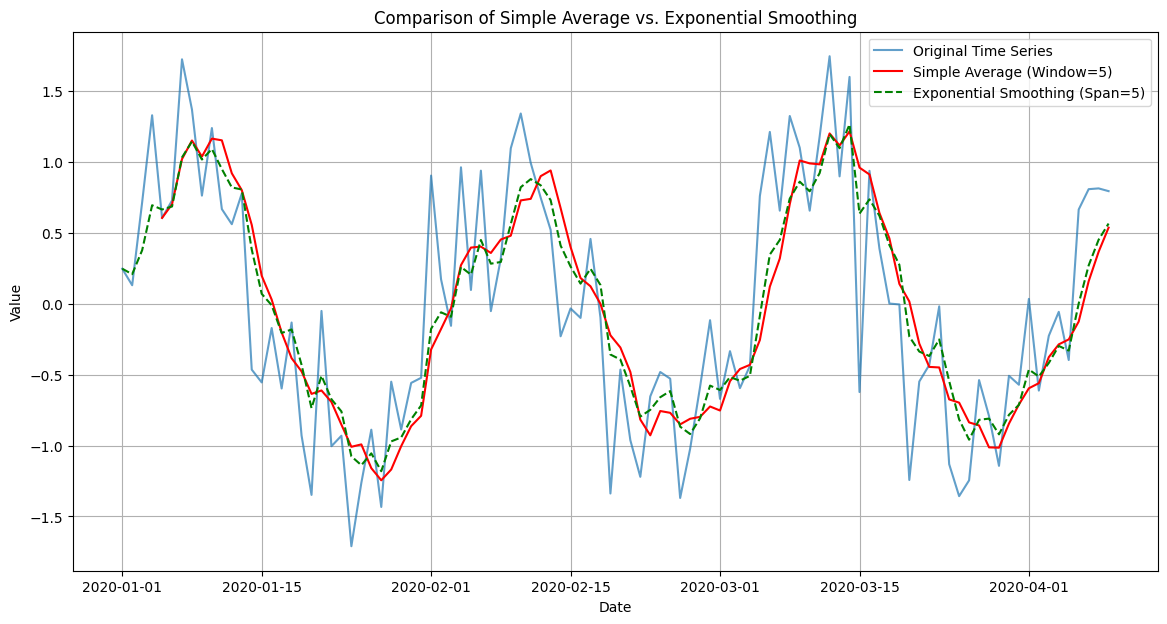

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
# 1. Generate a sample time series
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', periods=100, freq='D')
data = np.sin(np.linspace(0, 20, 100)) + np.random.normal(0, 0.5, 100)
ts = pd.Series(data, index=dates)

print("Original Time Series Head:")
print(ts.head(10))
print("\n")
# 2. Simple Average Smoothing (Moving Average)
window_size_simple = 5
simple_avg_smooth = ts.rolling(window=window_size_simple).mean()

print(f"Simple Average Smoothed Series (Window {window_size_simple}) Head:")
print(simple_avg_smooth.head(10))
print("\n")

# 3. Exponential Smoothing (Exponentially Weighted Moving Average - EWMA)

span_exp = 5
exp_smooth = ts.ewm(span=span_exp, adjust=False).mean()

print(f"Exponentially Smoothed Series (Span {span_exp}) Head:")
print(exp_smooth.head(10))
print("\n")

# 4. Plot the results for comparison
plt.figure(figsize=(14, 7))
plt.plot(ts, label='Original Time Series', alpha=0.7)
plt.plot(simple_avg_smooth, label=f'Simple Average (Window={window_size_simple})', color='red')
plt.plot(exp_smooth, label=f'Exponential Smoothing (Span={span_exp})', color='green', linestyle='--')

plt.title('Comparison of Simple Average vs. Exponential Smoothing')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()




/tmp/ipykernel_222/3975999514.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  initial_level=ts[0]


                       SimpleExpSmoothing Model Results                       
Dep. Variable:                   None   No. Observations:                  100
Model:             SimpleExpSmoothing   SSE                             39.011
Optimized:                      False   AIC                            -90.133
Trend:                           None   BIC                            -84.923
Seasonal:                        None   AICC                           -89.712
Seasonal Periods:                None   Date:                 Tue, 03 Mar 2026
Box-Cox:                        False   Time:                         22:12:37
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.3333333                alpha                False
initial_level              0.2483571                

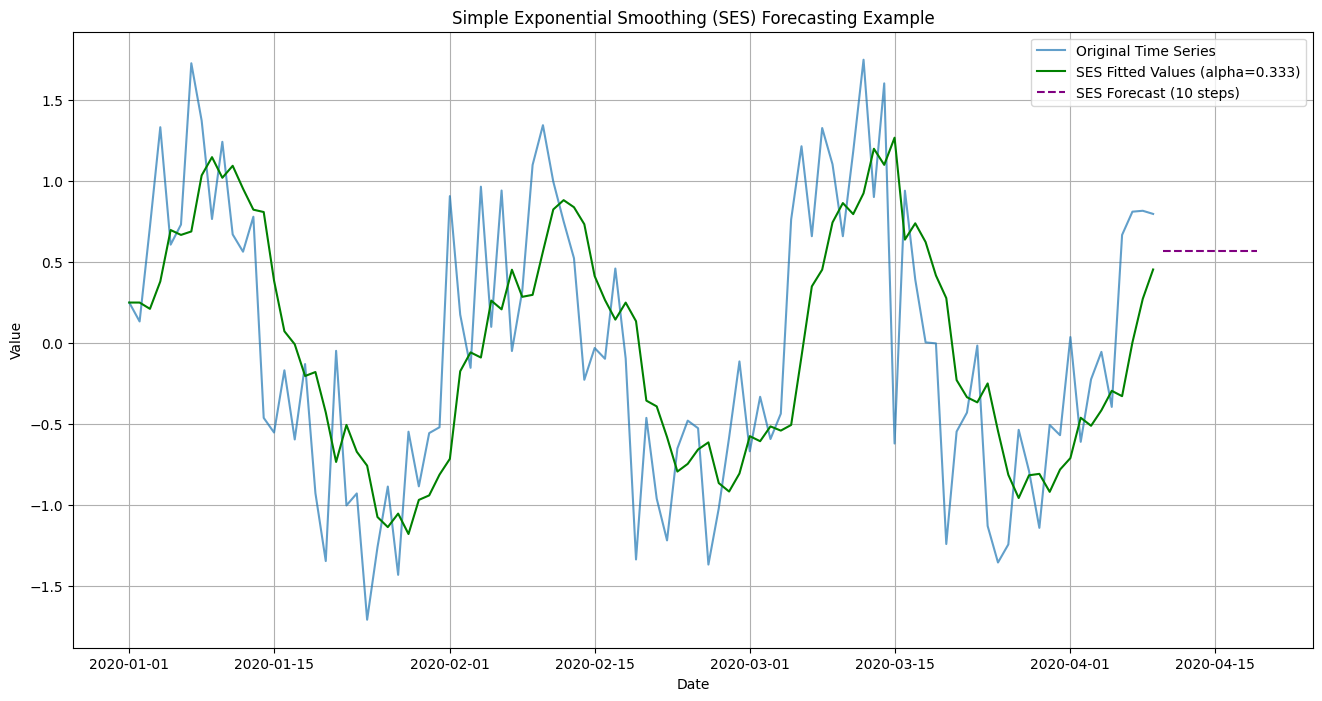

In [ ]:
# 1. Fit the Simple Exponential Smoothing model
alpha_for_ses = 2 / (1 + span_exp)
ses_model = SimpleExpSmoothing(
    ts,
    initialization_method='known',
    initial_level=ts[0]
).fit(smoothing_level=alpha_for_ses, optimized=False)

print(ses_model.summary())
# Get the fitted values (smoothed series)
ses_fitted_values = ses_model.fittedvalues

# 2. Generate a forecast
forecast_steps = 10
ses_forecast = ses_model.forecast(forecast_steps)

print(f"SES Fitted Values Head (using alpha={alpha_for_ses:.3f}):")
print(ses_fitted_values.head())
print("\n")
print(f"SES Forecast for next {forecast_steps} steps:")
print(ses_forecast)

# 3. Plot the original data, fitted values, and forecast
plt.figure(figsize=(16, 8))
plt.plot(ts, label='Original Time Series', alpha=0.7)
plt.plot(ses_fitted_values, label=f'SES Fitted Values (alpha={alpha_for_ses:.3f})', color='green', linestyle='-')
plt.plot(ses_forecast, label=f'SES Forecast ({forecast_steps} steps)', color='purple', linestyle='--')

plt.title('Simple Exponential Smoothing (SES) Forecasting Example')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


                              Holt Model Results                              
Dep. Variable:                   None   No. Observations:                  100
Model:                           Holt   SSE                             35.402
Optimized:                       True   AIC                            -95.841
Trend:                       Additive   BIC                            -85.420
Seasonal:                        None   AICC                           -94.938
Seasonal Periods:                None   Date:                 Tue, 03 Mar 2026
Box-Cox:                        False   Time:                         22:17:29
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.3792709                alpha                 True
smoothing_trend            0.3792709                

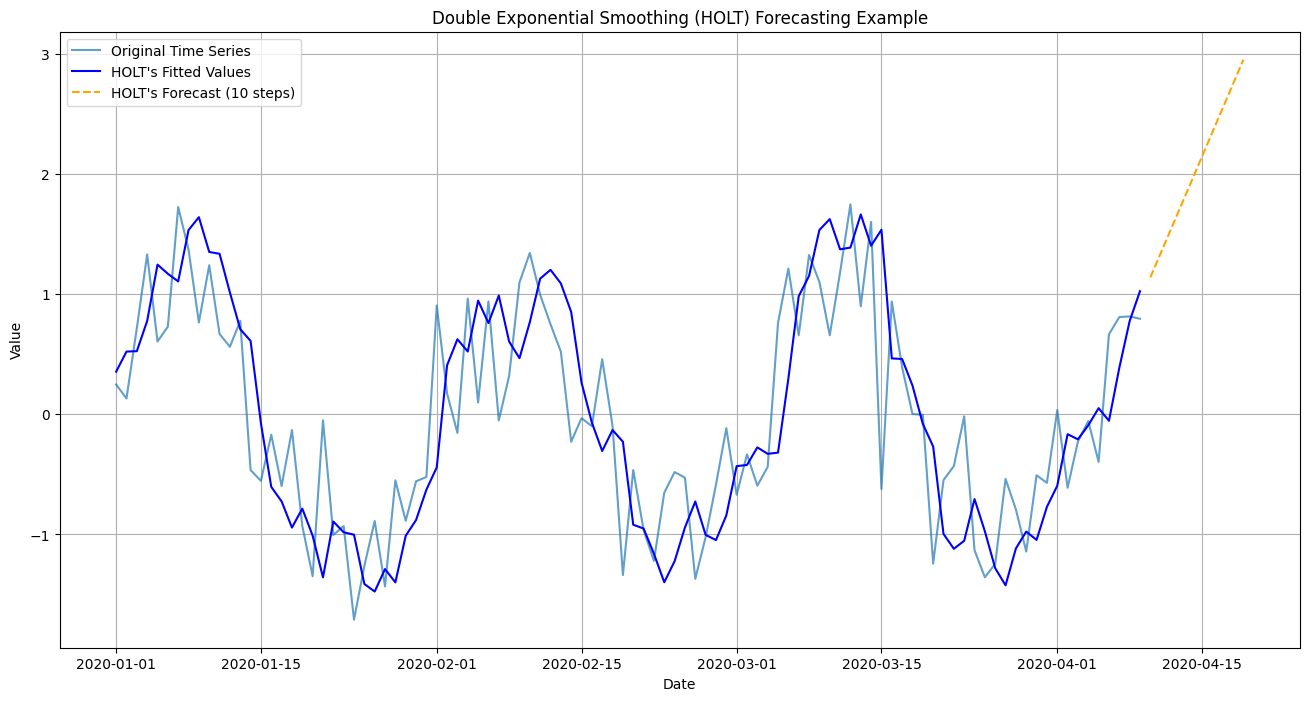

In [ ]:
# 1. Fit the Double Exponential Smoothing (Holt's Linear Trend) model
# We'll let the model optimize the smoothing parameters (alpha, beta)
# for the level and trend components.

holt_model = Holt(
    ts,
    initialization_method='estimated' # Let the model estimate initial level and trend
).fit(optimized=True)

print(holt_model.summary())

# Get the fitted values (smoothed series)
holt_fitted_values = holt_model.fittedvalues

# 2. Generate a forecast
forecast_steps_des = 10
holt_forecast = holt_model.forecast(forecast_steps_des)

print(f"\nHOLT's Fitted Values Head:")
print(holt_fitted_values.head())
print("\n")
print(f"HOLT's Forecast for next {forecast_steps_des} steps:")
print(holt_forecast)

# 3. Plot the original data, fitted values, and forecast
plt.figure(figsize=(16, 8))
plt.plot(ts, label='Original Time Series', alpha=0.7)
plt.plot(holt_fitted_values, label="HOLT's Fitted Values", color='blue', linestyle='-')
plt.plot(holt_forecast, label=f"HOLT's Forecast ({forecast_steps_des} steps)", color='orange', linestyle='--')

plt.title('Double Exponential Smoothing (HOLT) Forecasting Example')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

# 1. Fit the Triple Exponential Smoothing (ETS) model
# Assuming a weekly seasonality (7 days) for daily data

# Define model parameters
seasonal_periods_ets = 7 # Weekly seasonality for daily data

ets_model = ExponentialSmoothing(
    ts,
    seasonal_periods=seasonal_periods_ets,
    trend='add', # Additive trend
    seasonal='add', # Additive seasonality
    initialization_method='estimated'
).fit(optimized=True)

print(ets_model.summary())

# Get the fitted values (smoothed series)
ets_fitted_values = ets_model.fittedvalues

# 2. Generate a forecast
forecast_steps_ets = 14 # Forecast for two weeks
ets_forecast = ets_model.forecast(forecast_steps_ets)

print(f"\nETS Fitted Values Head:")
print(ets_fitted_values.head())
print("\n")
print(f"ETS Forecast for next {forecast_steps_ets} steps:")
print(ets_forecast)

                       ExponentialSmoothing Model Results                       
Dep. Variable:                     None   No. Observations:                  100
Model:             ExponentialSmoothing   SSE                             31.875
Optimized:                         True   AIC                            -92.335
Trend:                         Additive   BIC                            -63.678
Seasonal:                      Additive   AICC                           -88.102
Seasonal Periods:                     7   Date:                 Tue, 03 Mar 2026
Box-Cox:                          False   Time:                         22:20:07
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.5730728                alpha                 True
smoothing_trend          

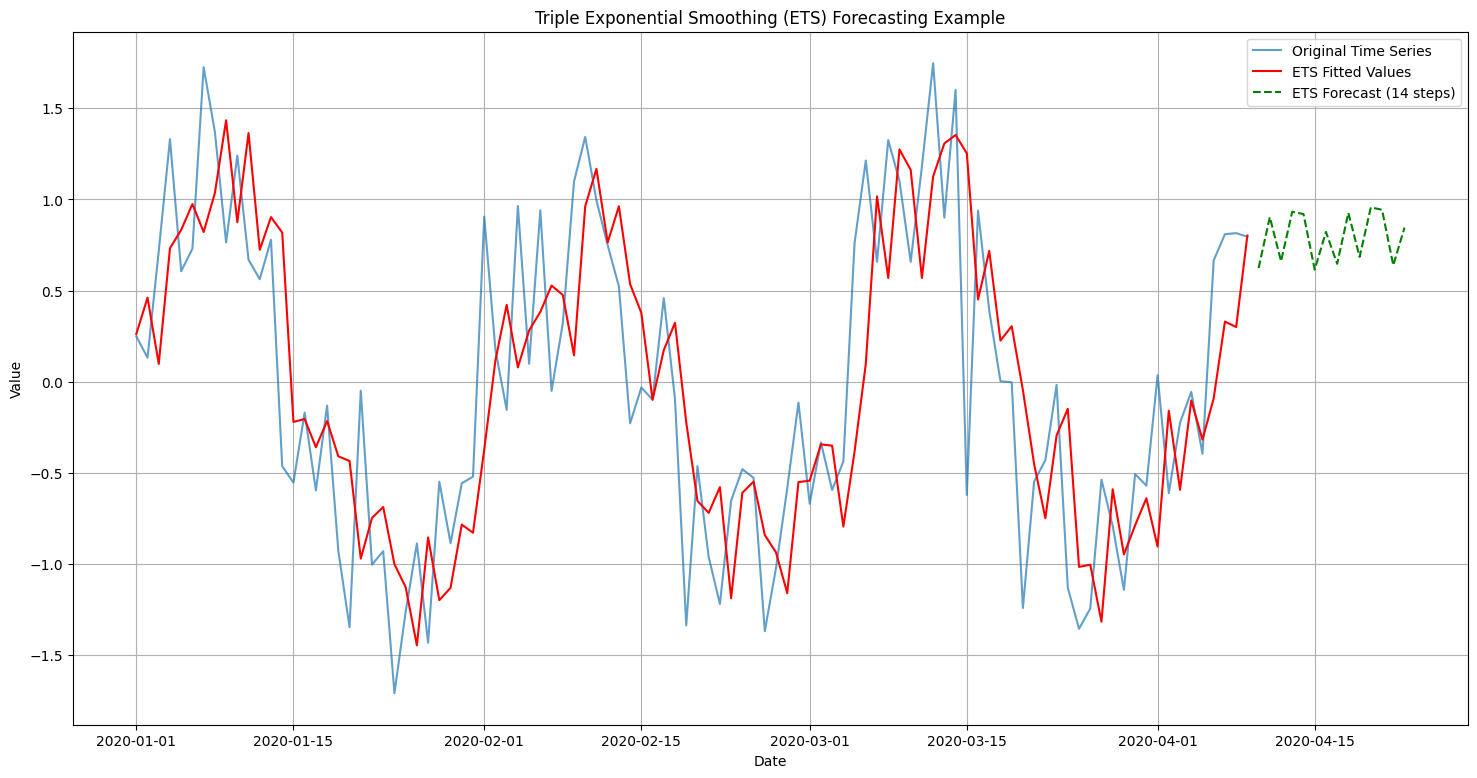

In [ ]:
# 3. Plot the original data, fitted values, and forecast
plt.figure(figsize=(18, 9))
plt.plot(ts, label='Original Time Series', alpha=0.7)
plt.plot(ets_fitted_values, label="ETS Fitted Values", color='red', linestyle='-')
plt.plot(ets_forecast, label=f"ETS Forecast ({forecast_steps_ets} steps)", color='green', linestyle='--')

plt.title('Triple Exponential Smoothing (ETS) Forecasting Example')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose


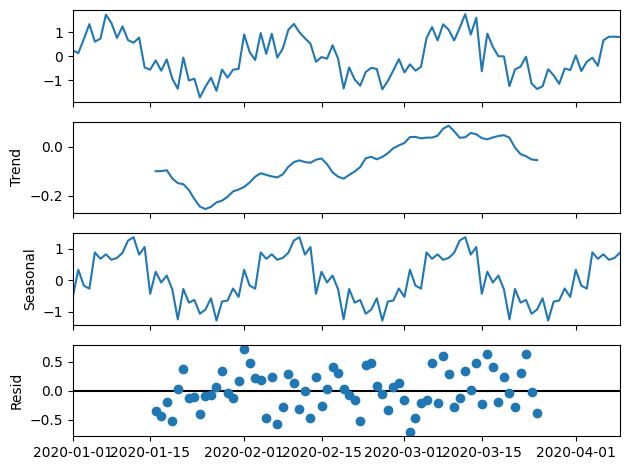

In [ ]:
result = seasonal_decompose(ts, model='additive', period=30)
result.plot()
plt.show()

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string


In [ ]:
pipeline = StatsForecast(
    models=[AutoARIMA(season_length=7,alias='arima_7'),
            AutoARIMA(season_length=30, alias='arima_30'),
            AutoARIMA( alias='arima_non-seasonal')],
    freq='D',
    n_jobs=-1
)

In [ ]:
train = ts.iloc[:80]
test = ts.iloc[80:]
df = pd.DataFrame({'ds':train.index,'y':train.to_numpy(), 'unique_id':'data'})
test_df = pd.DataFrame({'ds':test.index,'y':test.to_numpy(), 'unique_id':'data'})

In [ ]:
pipeline.fit(df)

StatsForecast(models=[arima_7,arima_30,arima_non-seasonal])

In [ ]:
print(arima_string(pipeline.fitted_[0,0].model_))
print(arima_string(pipeline.fitted_[0,1].model_))
print(arima_string(pipeline.fitted_[0,2].model_))


ARIMA(2,0,0) with zero mean    
ARIMA(0,0,0)(0,1,0)[30]                   
ARIMA(2,0,0) with zero mean    


<Axes: xlabel='ds'>

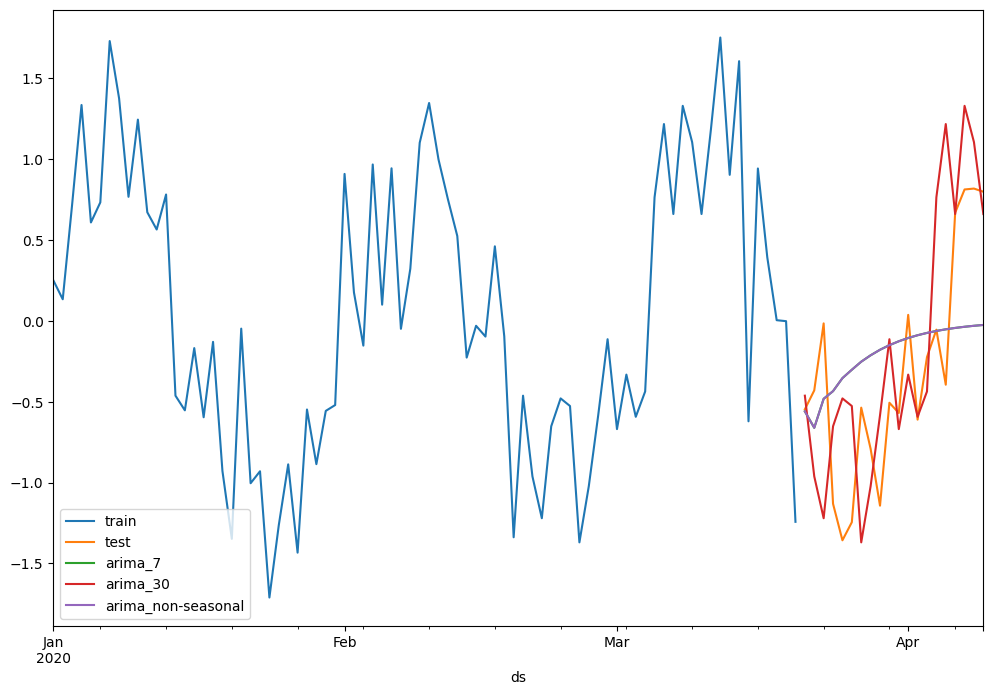

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(12, 8), sharex=True)

df.plot(x='ds', y='y', ax=axs, label='train')
test_df.plot(x='ds', y='y', ax=axs, label='test')
pipeline.predict(h=20).plot(x='ds', y=['arima_7',
                                       'arima_30',
                                       'arima_non-seasonal'
                                       ],ax=axs)